In [33]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

In [34]:
import os

# Locate project root regardless of who runs this notebook
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / ".git").exists():
        ROOT = _p
        break
else:
    ROOT = Path.cwd()
os.chdir(ROOT)
print(f"Project root: {ROOT}")

cleaned = pd.read_parquet(ROOT / "data/cleaned/hmof_dataset_cleaned.parquet")
rac     = pd.read_parquet(ROOT / "rac_features.parquet")

print(f"Cleaned:  {cleaned.shape}")
print(f"RAC:      {rac.shape}")
print(f"Name overlap: {rac['name'].isin(cleaned['name']).sum()} / {len(rac)}")

Project root: /Users/isabellamueller-vogt/Library/Mobile Documents/com~apple~CloudDocs/05 - ETH/06 - FS 2026/04 - Digital Chemistry/dc_project
Cleaned:  (111469, 27)
RAC:      (111469, 481)
Name overlap: 111469 / 111469


In [35]:
df = cleaned.merge(rac, on="name", how="inner")
print(f"Merged:   {df.shape}")
df.head(2)

Merged:   (111469, 507)


,name,pld,lcd,surface_area_m2g,surface_area_m2cm3,void_fraction,density_g_cm3,co2_mol_kg_0.01bar,co2_mol_kg_0.05bar,co2_mol_kg_0.1bar,...,racs_bb-nodes_prop-mod_pettifor_scope-2_propagg-product_corragg-sum_bbagg-avg,racs_bb-nodes_prop-mod_pettifor_scope-2_propagg-product_corragg-sum_bbagg-sum,racs_bb-nodes_prop-mod_pettifor_scope-3_propagg-diff_corragg-avg_bbagg-avg,racs_bb-nodes_prop-mod_pettifor_scope-3_propagg-diff_corragg-avg_bbagg-sum,racs_bb-nodes_prop-mod_pettifor_scope-3_propagg-diff_corragg-sum_bbagg-avg,racs_bb-nodes_prop-mod_pettifor_scope-3_propagg-diff_corragg-sum_bbagg-sum,racs_bb-nodes_prop-mod_pettifor_scope-3_propagg-product_corragg-avg_bbagg-avg,racs_bb-nodes_prop-mod_pettifor_scope-3_propagg-product_corragg-avg_bbagg-sum,racs_bb-nodes_prop-mod_pettifor_scope-3_propagg-product_corragg-sum_bbagg-avg,racs_bb-nodes_prop-mod_pettifor_scope-3_propagg-product_corragg-sum_bbagg-sum
0,hMOF-6,9.75,10.75,3174.5,2227.6,0.754903,0.701717,0.107653,0.702453,1.190170,...,34821.0,139284.0,21.125,84.5,338.0,1352.0,6871.125,27484.5,109938.0,439752.0
1,hMOF-0,10.75,11.75,3676.3,2262.5,0.795539,0.615429,0.022406,0.073552,0.225851,...,34821.0,139284.0,21.125,84.5,338.0,1352.0,6871.125,27484.5,109938.0,439752.0


In [36]:
# define feature/target columns
CO2_PRESSURES = [0.01, 0.05, 0.1, 0.5, 2.5]
TARGET_COLS   = [f"co2_mol_kg_{p}bar" for p in CO2_PRESSURES]

GEO_COLS = [
    "pld", "lcd", "surface_area_m2g", "surface_area_m2cm3",
    "void_fraction", "density_g_cm3",
]

# Exclude bb-linker features: ~28% missing (MOFs without functional linkers)
RAC_COLS = [c for c in df.columns if c.startswith("racs_") and "bb-linker" not in c]

FEATURE_COLS = GEO_COLS + RAC_COLS

print(f"Geometric features:  {len(GEO_COLS)}")
print(f"RAC features:        {len(RAC_COLS)}")
print(f"Total features:      {len(FEATURE_COLS)}")
print(f"Target columns:      {TARGET_COLS}")

Geometric features:  6
RAC features:        96
Total features:      102
Target columns:      ['co2_mol_kg_0.01bar', 'co2_mol_kg_0.05bar', 'co2_mol_kg_0.1bar', 'co2_mol_kg_0.5bar', 'co2_mol_kg_2.5bar']


In [37]:
# check for missing values
missing = df[FEATURE_COLS].isnull().sum()
missing_pct = missing / len(df) * 100

has_missing = missing[missing > 0]
if len(has_missing) == 0:
    print("No missing values in feature columns.")
else:
    print(f"{len(has_missing)} feature columns have missing values:")
    display(
        pd.DataFrame({"n_missing": has_missing, "pct_missing": missing_pct[has_missing.index]})
        .sort_values("pct_missing", ascending=False)
    )

# Fill geometric NaN (density_g_cm3 has 2.6% missing) with median for analysis
X = df[FEATURE_COLS].copy()
for col in X.columns[X.isnull().any()]:
    X[col].fillna(X[col].median(), inplace=True)
print(f"\nFeature matrix after imputation: {X.shape}, NaNs: {X.isnull().sum().sum()}")

97 feature columns have missing values:


,n_missing,pct_missing
density_g_cm3,2889,2.591752
racs_bb-nodes_prop-X_scope-1_propagg-diff_corragg-avg_bbagg-avg,5,0.004486
racs_bb-nodes_prop-X_scope-3_propagg-product_corragg-sum_bbagg-avg,5,0.004486
racs_bb-nodes_prop-X_scope-3_propagg-product_corragg-avg_bbagg-sum,5,0.004486
racs_bb-nodes_prop-X_scope-3_propagg-product_corragg-avg_bbagg-avg,5,0.004486
...,...,...
racs_bb-nodes_prop-T_scope-1_propagg-product_corragg-avg_bbagg-sum,5,0.004486
racs_bb-nodes_prop-T_scope-1_propagg-product_corragg-avg_bbagg-avg,5,0.004486
racs_bb-nodes_prop-T_scope-1_propagg-diff_corragg-sum_bbagg-sum,5,0.004486
racs_bb-nodes_prop-T_scope-1_propagg-diff_corragg-sum_bbagg-avg,5,0.004486



Feature matrix after imputation: (111469, 102), NaNs: 0


/var/folders/xv/yz626hgx6zj5m96hny2lqlrc0000gn/T/ipykernel_45838/1370809673.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].median(), inplace=True)


### Correlation analysis

Features with variance < 1e-06: 15
racs_bb-nodes_prop-I_scope-1_propagg-diff_corragg-avg_bbagg-avg       0.0
racs_bb-nodes_prop-I_scope-1_propagg-diff_corragg-avg_bbagg-sum       0.0
racs_bb-nodes_prop-I_scope-1_propagg-diff_corragg-sum_bbagg-avg       0.0
racs_bb-nodes_prop-I_scope-1_propagg-diff_corragg-sum_bbagg-sum       0.0
racs_bb-nodes_prop-I_scope-1_propagg-product_corragg-avg_bbagg-avg    0.0
racs_bb-nodes_prop-I_scope-2_propagg-diff_corragg-avg_bbagg-avg       0.0
racs_bb-nodes_prop-I_scope-2_propagg-diff_corragg-avg_bbagg-sum       0.0
racs_bb-nodes_prop-I_scope-2_propagg-diff_corragg-sum_bbagg-avg       0.0
racs_bb-nodes_prop-I_scope-2_propagg-diff_corragg-sum_bbagg-sum       0.0
racs_bb-nodes_prop-I_scope-2_propagg-product_corragg-avg_bbagg-avg    0.0
racs_bb-nodes_prop-I_scope-3_propagg-diff_corragg-avg_bbagg-avg       0.0
racs_bb-nodes_prop-I_scope-3_propagg-diff_corragg-avg_bbagg-sum       0.0
racs_bb-nodes_prop-I_scope-3_propagg-diff_corragg-sum_bbagg-avg       0.0
rac

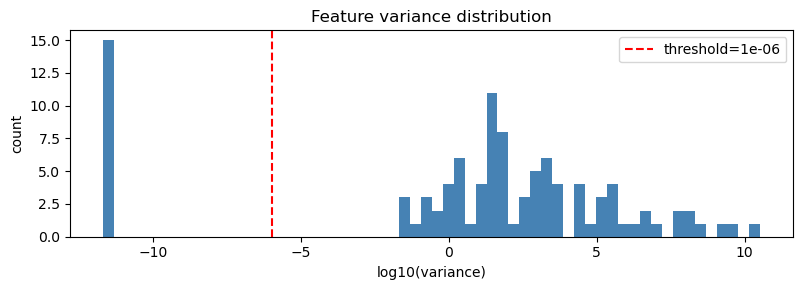

In [38]:
# Near-zero variance
VARIANCE_THRESHOLD = 1e-6

variances = X.var()
low_var   = variances[variances < VARIANCE_THRESHOLD]

print(f"Features with variance < {VARIANCE_THRESHOLD}: {len(low_var)}")
if len(low_var) > 0:
    print(low_var.sort_values().head(20).to_string())

# Distribution of variances
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(np.log10(variances.clip(lower=1e-12) + 1e-12), bins=60, color="steelblue", edgecolor="none")
ax.axvline(np.log10(VARIANCE_THRESHOLD), color="red", linestyle="--", label=f"threshold={VARIANCE_THRESHOLD}")
ax.set_xlabel("log10(variance)")
ax.set_ylabel("count")
ax.set_title("Feature variance distribution")
ax.legend()
plt.tight_layout()
plt.show()

#### Feature–feature Pearson correlation

In [39]:
# Use random-split training names for the correlation analysis
train_df = pd.read_parquet(ROOT / "data/splits/split_random_train.parquet")
train_names = set(train_df["name"])
train_mask  = df["name"].isin(train_names)

X_train = X[train_mask].reset_index(drop=True)
print(f"Training rows used for correlation analysis: {len(X_train)}")

Training rows used for correlation analysis: 89175


Total feature pairs: 3,741
|r| > 0.90: 304
|r| > 0.95: 122
|r| > 0.99: 18


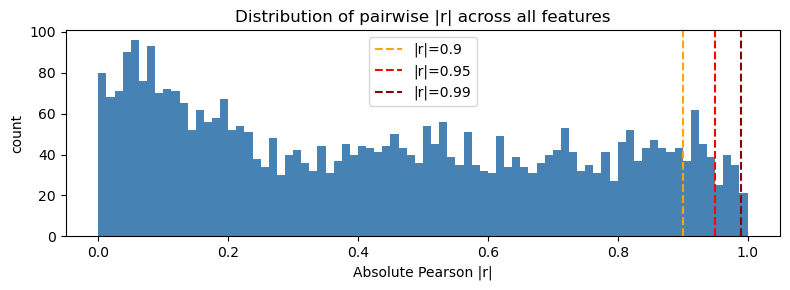

In [40]:
# Compute Pearson correlation matrix (on training set)
corr_matrix = X_train.corr(method="pearson")

# Histogram of all pairwise |r| values (upper triangle, excluding diagonal)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
flat_r = upper.stack().abs()

print(f"Total feature pairs: {len(flat_r):,}")
print(f"|r| > 0.90: {(flat_r > 0.90).sum():,}")
print(f"|r| > 0.95: {(flat_r > 0.95).sum():,}")
print(f"|r| > 0.99: {(flat_r > 0.99).sum():,}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(flat_r, bins=80, color="steelblue", edgecolor="none")
for thresh, col in [(0.90, "orange"), (0.95, "red"), (0.99, "darkred")]:
    ax.axvline(thresh, color=col, linestyle="--", label=f"|r|={thresh}")
ax.set_xlabel("Absolute Pearson |r|")
ax.set_ylabel("count")
ax.set_title("Distribution of pairwise |r| across all features")
ax.legend()
plt.tight_layout()
plt.show()

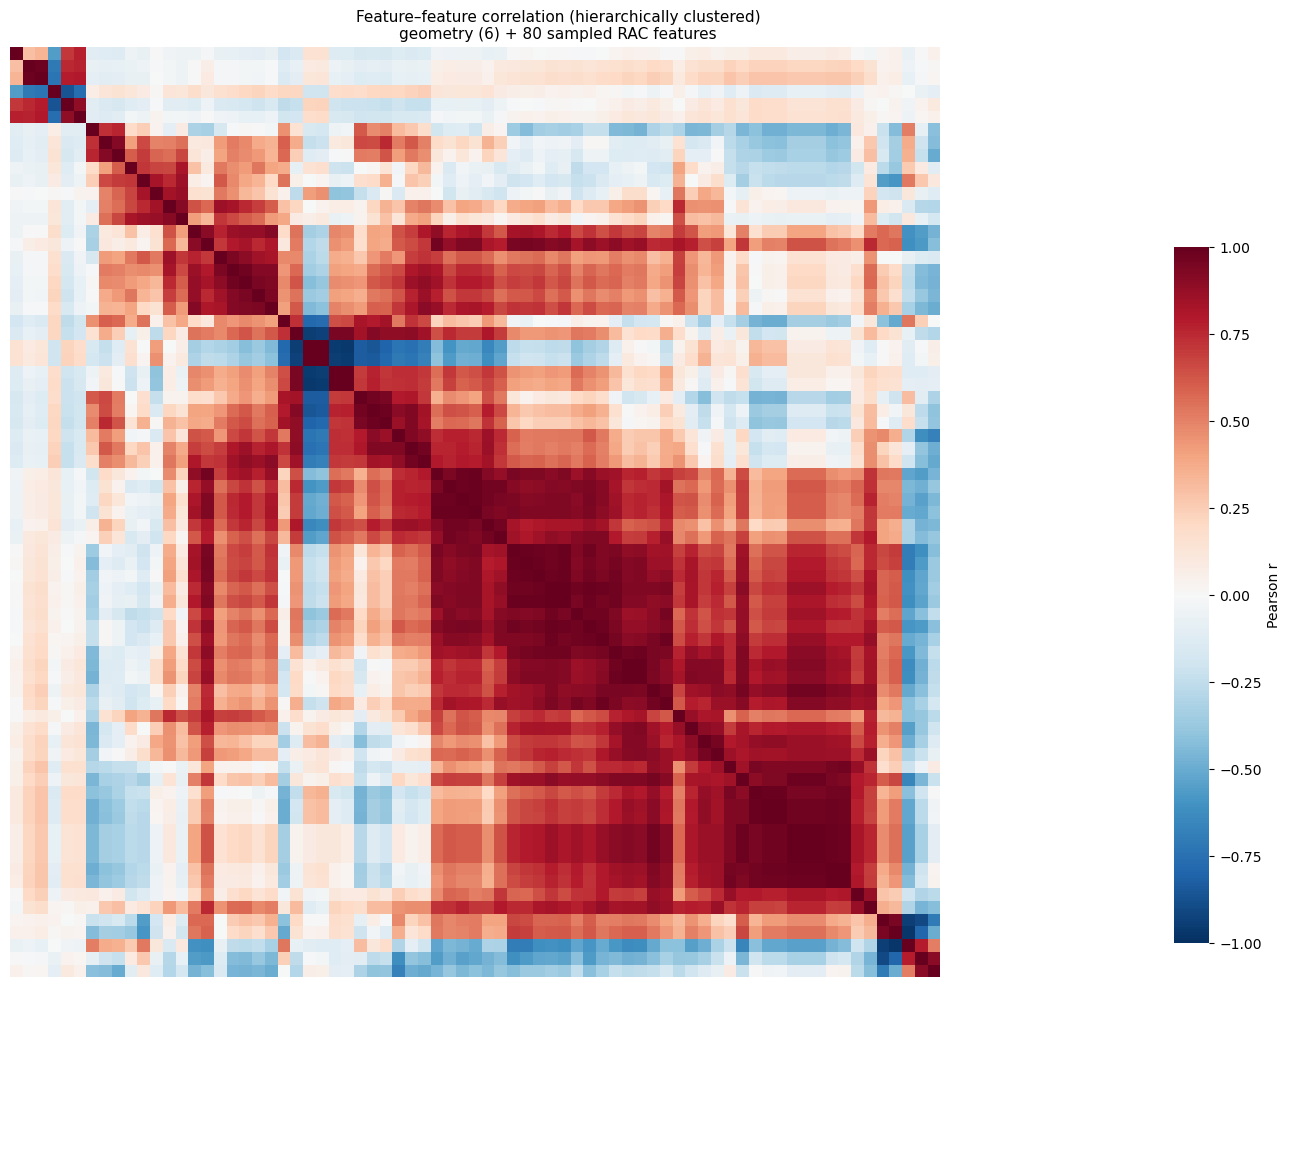

In [ ]:
# Clustered correlation heatmap — subsample features for readability
# Show geometry features + a random sample of RAC features
N_RAC_SAMPLE = min(80, len(RAC_COLS))
rng = np.random.default_rng(42)
rac_sample = rng.choice(RAC_COLS, size=N_RAC_SAMPLE, replace=False).tolist()
viz_cols = GEO_COLS + rac_sample

corr_viz = corr_matrix.loc[viz_cols, viz_cols]

# Hierarchical clustering order
# NaN entries (zero-variance features) → treat as uncorrelated (distance = 1)
dist_np = np.clip(1 - np.nan_to_num(corr_viz.abs().values, nan=0.0), 0, None)
condensed = dist_np[np.triu_indices(len(dist_np), k=1)]
linkage = hierarchy.linkage(condensed, method="average")
order   = hierarchy.leaves_list(linkage)
reordered = corr_viz.iloc[order, order]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    reordered,
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    square=True, xticklabels=False, yticklabels=False,
    cbar_kws={"shrink": 0.6, "label": "Pearson r"},
    ax=ax,
)
ax.set_title(f"Feature–feature correlation (hierarchically clustered)\n"
             f"geometry ({len(GEO_COLS)}) + {N_RAC_SAMPLE} sampled RAC features", fontsize=11)
plt.tight_layout()
plt.show()

/opt/miniconda3/envs/IML/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/IML/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


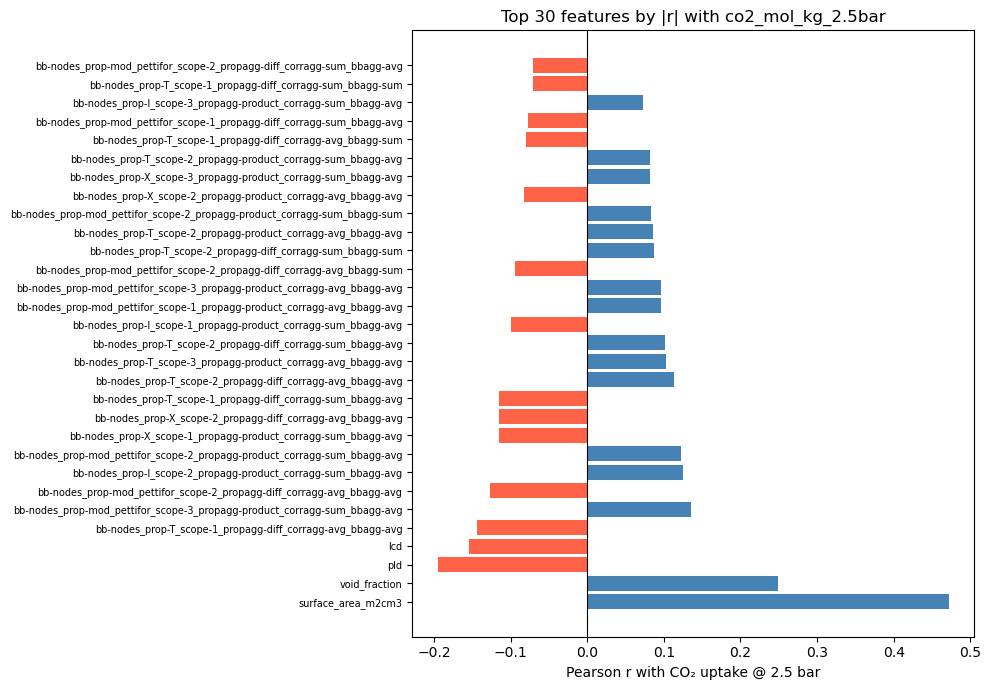

In [42]:
# Feature–target correlation
y_train = df.loc[train_mask, TARGET_COLS].reset_index(drop=True)

# Pearson r between each feature and each target
feat_target_r = pd.DataFrame(
    {t: X_train.corrwith(y_train[t]) for t in TARGET_COLS}
)

# Focus on highest-pressure target for ranking
target_main = "co2_mol_kg_2.5bar"
top_n = 30

top_feat = feat_target_r[target_main].abs().nlargest(top_n).index
top_r    = feat_target_r.loc[top_feat, target_main]

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["steelblue" if v >= 0 else "tomato" for v in top_r]
ax.barh(range(top_n), top_r.values, color=colors, edgecolor="none")
ax.set_yticks(range(top_n))
ax.set_yticklabels(
    [c.replace("racs_", "") for c in top_r.index],
    fontsize=7,
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson r with CO₂ uptake @ 2.5 bar")
ax.set_title(f"Top {top_n} features by |r| with {target_main}")
plt.tight_layout()
plt.show()

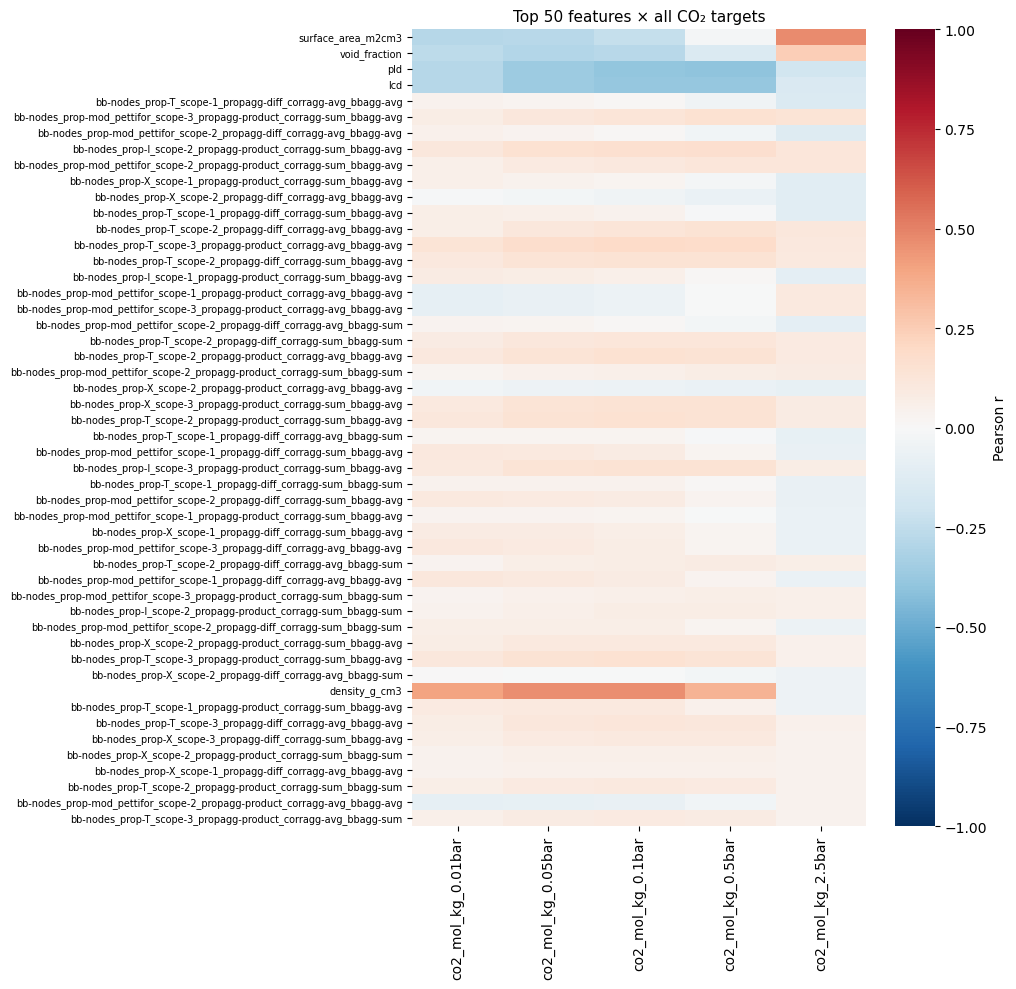

In [43]:
# Heatmap: top features vs all targets
top50 = feat_target_r[target_main].abs().nlargest(50).index

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    feat_target_r.loc[top50],
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=False, yticklabels=[c.replace("racs_", "") for c in top50],
    cbar_kws={"label": "Pearson r"},
    ax=ax,
)
ax.set_title("Top 50 features × all CO₂ targets", fontsize=11)
ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.show()

5. Decorrelation

1. **Near-zero variance filter**: drop features with variance < threshold
2. **High-correlation filter**: for each pair with |r| > `CORR_THRESHOLD`, keep the feature with higher mean |r| to the targets (more predictive); drop the other

In [ ]:
CORR_THRESHOLD = 0.95   # drop one feature from pairs with |r| > this

# ── Step 1: near-zero variance ──────────────────────────────────────────────
dropped_low_var = low_var.index.tolist()
kept_after_var  = [c for c in FEATURE_COLS if c not in dropped_low_var]

print(f"removed {len(dropped_low_var)} near-zero-variance features.")
print(f"Remaining: {len(kept_after_var)} features.")

Step 1 — removed 15 near-zero-variance features.
         Remaining: 87 features.


In [ ]:
# Step 2: high-correlation filter
# Work on the correlation submatrix of surviving features
corr_sub = corr_matrix.loc[kept_after_var, kept_after_var]

# Mean |r| with all targets: used to break ties (keep more predictive feature)
mean_target_r = feat_target_r.loc[kept_after_var].abs().mean(axis=1)

to_drop = set()
cols = list(corr_sub.columns)

for i in range(len(cols)):
    if cols[i] in to_drop:
        continue
    for j in range(i + 1, len(cols)):
        if cols[j] in to_drop:
            continue
        if abs(corr_sub.iloc[i, j]) > CORR_THRESHOLD:
            # Drop the one with lower mean |r| to targets
            if mean_target_r.get(cols[i], 0) >= mean_target_r.get(cols[j], 0):
                to_drop.add(cols[j])
            else:
                to_drop.add(cols[i])
                break  # cols[i] is dropped; move to next i

kept_after_corr = [c for c in kept_after_var if c not in to_drop]

print(f"Removed {len(to_drop)} highly-correlated features (|r| > {CORR_THRESHOLD}).")
print(f"Remaining: {len(kept_after_corr)} features.")

Step 2 — removed 37 highly-correlated features (|r| > 0.95).
         Remaining: 50 features.


In [ ]:
FINAL_FEATURES = kept_after_corr

geo_kept = [c for c in FINAL_FEATURES if c in GEO_COLS]
rac_kept = [c for c in FINAL_FEATURES if c.startswith("racs_")]

print("Feature selection summary")
print(f"  Started with: {len(FEATURE_COLS):>5} features")
print(f"  Dropped (low variance): {len(dropped_low_var):>5}")
print(f"  Dropped (high corr): {len(to_drop):>5}")
print(f"  Final feature count: {len(FINAL_FEATURES):>5}")
print(f"    of which geometry: {len(geo_kept):>5}")
print(f"    of which RAC: {len(rac_kept):>5}")

=== Feature selection summary ===
  Started with:                102 features
  Dropped (low variance):       15
  Dropped (high corr):          37
  Final feature count:          50
    of which geometry:           5
    of which RAC:               45


Max |r| among kept features: 0.9499  (should be ≤ 0.95)


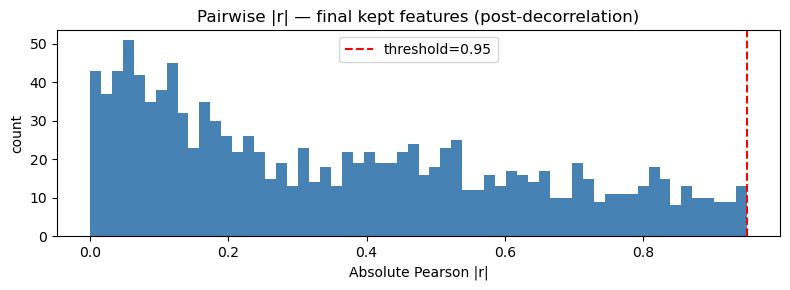

In [ ]:
# Verify: max |r| among kept features
corr_final = corr_matrix.loc[FINAL_FEATURES, FINAL_FEATURES]
upper_final = corr_final.where(np.triu(np.ones(corr_final.shape), k=1).astype(bool))
flat_final  = upper_final.stack().abs()

print(f"Max |r| among kept features: {flat_final.max():.4f}  (should be ≤ {CORR_THRESHOLD})")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(flat_final, bins=60, color="steelblue", edgecolor="none")
ax.axvline(CORR_THRESHOLD, color="red", linestyle="--", label=f"threshold={CORR_THRESHOLD}")
ax.set_xlabel("Absolute Pearson |r|")
ax.set_ylabel("count")
ax.set_title("Pairwise |r|: final kept features (post-decorrelation)")
ax.legend()
plt.tight_layout()
plt.show()

6. Save merged & decorrelated datasets

We apply the same feature selection to all splits and save:
- `data/merged/hmof_merged.parquet` — full merged dataset (all features)
- `data/merged/hmof_decorrelated.parquet` — full dataset with final feature set only
- `data/splits/split_{strategy}_{partition}_merged.parquet` — per-split merged files

In [ ]:
MERGED_DIR = ROOT / "data/merged"
MERGED_DIR.mkdir(parents=True, exist_ok=True)

META_COLS = ["name", "topology", "metal_node", "elements", "mofid", "mofkey", "database", "mofdb_id"]
SAVE_COLS = META_COLS + TARGET_COLS + FINAL_FEATURES

# Full merged (all features + targets + metadata)
full_merged = df[META_COLS + TARGET_COLS + FEATURE_COLS]
full_merged.to_parquet(MERGED_DIR / "hmof_merged.parquet", index=False)
print(f"Saved hmof_merged.parquet {full_merged.shape}")

# Full merged — decorrelated feature set only
decorrelated = df[SAVE_COLS]
decorrelated.to_parquet(MERGED_DIR / "hmof_decorrelated.parquet", index=False)
print(f"Saved hmof_decorrelated.parquet {decorrelated.shape}")

Saved hmof_merged.parquet          (111469, 115)
Saved hmof_decorrelated.parquet    (111469, 63)


In [49]:
# Save per-split decorrelated files
SPLITS_DIR = ROOT / "data/splits"

strategies  = ["random", "metal", "topology"]
partitions  = ["train", "val", "test"]

# Build a lookup: name → row in decorrelated df
decor_indexed = decorrelated.set_index("name")

for strategy in strategies:
    for partition in partitions:
        split_path = SPLITS_DIR / f"split_{strategy}_{partition}.parquet"
        if not split_path.exists():
            print(f"  SKIP (not found): {split_path.name}")
            continue

        split_names = pd.read_parquet(split_path, columns=["name"])["name"]
        split_decor = decor_indexed.loc[split_names].reset_index()

        out_path = SPLITS_DIR / f"split_{strategy}_{partition}_merged.parquet"
        split_decor.to_parquet(out_path, index=False)
        print(f"  Saved {out_path.name}  {split_decor.shape}")

  Saved split_random_train_merged.parquet  (89175, 63)
  Saved split_random_val_merged.parquet  (11147, 63)
  Saved split_random_test_merged.parquet  (11147, 63)
  Saved split_metal_train_merged.parquet  (78241, 63)
  Saved split_metal_val_merged.parquet  (3994, 63)
  Saved split_metal_test_merged.parquet  (29234, 63)
  Saved split_topology_train_merged.parquet  (8809, 63)
  Saved split_topology_val_merged.parquet  (1048, 63)
  Saved split_topology_test_merged.parquet  (101612, 63)


In [ ]:
# Save feature list for downstream use
import json
feature_info = {
    "feature_cols": FINAL_FEATURES,
    "geo_cols":     geo_kept,
    "rac_cols":     rac_kept,
    "target_cols":  TARGET_COLS,
    "corr_threshold": CORR_THRESHOLD,
    "variance_threshold": VARIANCE_THRESHOLD,
    "n_total_before": len(FEATURE_COLS),
    "n_dropped_low_var": len(dropped_low_var),
    "n_dropped_high_corr": len(to_drop),
    "n_final": len(FINAL_FEATURES),
}
(MERGED_DIR / "feature_selection.json").write_text(json.dumps(feature_info, indent=2))
print("Saved feature_selection.json")
print(f"\nFinal feature set: {len(FINAL_FEATURES)} features")
print(f"  Geometry: {len(geo_kept)}")
print(f"  RAC: {len(rac_kept)}")

Saved feature_selection.json

Final feature set: 50 features
  Geometry: 5
  RAC:      45
